In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read market data
df = pd.read_csv('../real-data-treated/usa_n3522_m2440_yr2010_filled.csv', index_col=0, parse_dates=True)
df.head()

,AAL,AIR,AIRI,AIRT,ALGT,ALK,ASTC,ATRO,ATSG,AVAV,...,TRNS,URI,USM,VEON,VOD,WCC,WLFC,WSO,WTRG,YORW
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,4.496876,21.401571,39.339664,5.638029,40.233162,7.774136,286.5,2.833325,2.80,29.610001,...,7.45,10.04,36.015179,481.802826,11.630528,27.580000,14.77,32.134510,10.025703,11.277903
2010-01-05,5.005957,21.815735,39.339664,5.721555,41.632645,8.199961,292.5,2.750533,2.62,29.000000,...,6.62,9.93,35.998024,496.210541,11.545262,27.780001,14.56,31.254126,10.054380,11.133990
2010-01-06,4.798555,22.914175,39.339664,5.721555,41.691303,8.126390,291.0,2.670808,2.47,28.590000,...,7.06,9.93,35.680672,500.850311,11.454986,28.750000,14.17,31.467731,10.071585,10.800728
2010-01-07,4.939965,23.274321,39.339664,5.697690,41.573986,8.084030,291.0,2.695339,2.69,28.719999,...,7.12,9.80,35.208931,506.955261,11.239326,29.170000,14.01,31.953251,10.088791,10.770434
2010-01-08,4.845690,22.905169,39.339664,5.733488,41.096325,7.923509,292.5,2.713737,2.66,29.080000,...,7.15,9.58,34.651424,498.652466,11.068810,29.200001,14.02,31.869093,10.134675,10.815878


In [3]:
# Portfolio problem

# Get the returns of the assets
returns = df.pct_change().dropna()
returns_mean = returns.mean().to_numpy()

# Get the covariance matrix
cov_matrix = returns.cov().to_numpy()

# import Gurobi
from gurobipy import *

# Create the portfolio optimization model
m = Model('portfolio')

# Add the variables to the model
w = m.addMVar(len(returns_mean), lb=0.0, vtype=GRB.CONTINUOUS, name='weights')

# Add the constraint to the model
m.addConstr(w.sum() == 1.0, 'budget')

frontier = [['return', 'variance', 'alpha']]
for alpha in np.arange(0.9, 1.11, 0.005):
    # Set the objective function as the wieghted sum of portfolio variance and portfolio return
    portfolio_variance = w @ cov_matrix @ w
    portfolio_return = w @ returns_mean
    m.setObjective(alpha * portfolio_variance - (1-alpha) * portfolio_return, GRB.MINIMIZE)

    # Optimize the model
    m.optimize()

    # Get the weights
    weights = w.x
    print(weights)

    # Get the portfolio return and variance
    portfolio_return = returns_mean @ weights
    portfolio_variance = weights @ cov_matrix @ weights
    frontier.append([portfolio_return, portfolio_variance, alpha])

frontier = pd.DataFrame(frontier[1:], columns=frontier[0])
frontier.set_index('alpha', inplace=True)

Set parameter Username
Academic license - for non-commercial use only - expires 2024-08-26
Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 1 rows, 2440 columns and 2440 nonzeros
Model fingerprint: 0x0e8b7afd
Model has 2978020 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-08, 1e-01]
  QObjective range [5e-10, 9e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve time: 0.34s
Presolved: 1 rows, 2440 columns, 2440 nonzeros
Presolved model has 2978020 quadratic objective terms
Ordering time: 0.02s

Barrier statistics:
 Free vars  : 2439
 AA' NZ     : 2.976e+06
 Factor NZ  : 2.978e+06 (roughly 27 MB of memory)
 Factor Ops : 4.845e+09 (less than 1 second per iteration)
 Threads    : 8

      

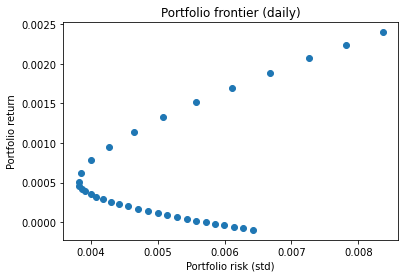

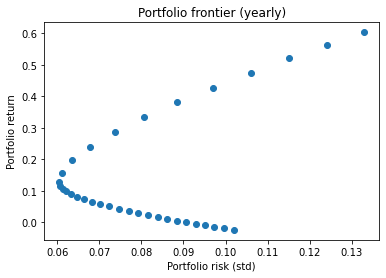

In [4]:
# Change daily variance and return to annual variance and return
frontier['variance_anual'] = frontier['variance'] * 252
frontier['return_anual'] = frontier['return'] * 252

# Scatter plot of the portfolio frontier
frontier_sub = frontier[frontier['variance_anual'] < 0.02]
plt.scatter(np.sqrt(frontier_sub['variance']), frontier_sub['return'])
plt.xlabel('Portfolio risk (std)')
plt.ylabel('Portfolio return')
plt.title('Portfolio frontier (daily)')
plt.show()
plt.scatter(np.sqrt(frontier_sub['variance_anual']), frontier_sub['return_anual'])
plt.xlabel('Portfolio risk (std)')
plt.ylabel('Portfolio return')
plt.title('Portfolio frontier (yearly)')
plt.show()

In [6]:
frontier_sub.describe()

,return,variance,variance_anual,return_anual
count,34.000000,34.000000,34.000000,34.000000
mean,0.000599,0.000028,0.007175,0.151049
std,0.000735,0.000014,0.003448,0.185305
min,-0.000097,0.000015,0.003665,-0.024562
25%,0.000070,0.000018,0.004455,0.017725
50%,0.000304,0.000025,0.006397,0.076683
75%,0.000911,0.000035,0.008944,0.229453
max,0.002396,0.000070,0.017645,0.603899


In [7]:
frontier_sub

,return,variance,variance_anual,return_anual
alpha,,,,
0.945,2.396425e-03,0.000070,0.017645,0.603899
0.950,2.234296e-03,0.000061,0.015382,0.563043
0.955,2.065629e-03,0.000053,0.013263,0.520539
0.960,1.886445e-03,0.000045,0.011262,0.475384
0.965,1.699258e-03,0.000037,0.009424,0.428213
0.970,1.512124e-03,0.000031,0.007839,0.381055
0.975,1.324816e-03,0.000026,0.006504,0.333854
0.980,1.138184e-03,0.000022,0.005421,0.286822
0.985,9.537789e-04,0.000018,0.004593,0.240352
